# Car Price Prediction:


**Task**
*   Collect car-related features like brand goodwill, horsepower, mileage, etc.
*   Train a regression model to predict car prices based on these features.
*   Handle data preprocessing, feature engineering, and model evaluation
*   Use Python libraries like Pandas, Scikit-learn and Matplotlib for the workflow.
*   Understand real-world applications of machine learning in price prediction.



## Step 1: Data Preprocessing

In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [209]:
# Load dataset
df = pd.read_csv('CarPrice_Assignment.csv')

In [210]:
# Cleaning brands
df['brand'] = df['CarName'].str.split().str[0].str.lower()
df['brand'] = df['brand'].replace({
    'maxda': 'mazda', 'porcshce': 'porsche', 'toyouta': 'toyota',
    'vokswagen': 'volkswagen', 'vw': 'volkswagen'
})


In [211]:
df = df.drop(columns=['car_ID', 'CarName'])
display(df.head())

,symboling,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,carlength,carwidth,...,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price,brand
0,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0,alfa-romero
1,3,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,...,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0,alfa-romero
2,1,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0,alfa-romero
3,2,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,...,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0,audi
4,2,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,...,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0,audi


In [212]:
df.shape

(205, 25)

In [213]:
df.describe()

,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [214]:
df.dtypes

,0
symboling,int64
fueltype,object
aspiration,object
doornumber,object
carbody,object
drivewheel,object
enginelocation,object
wheelbase,float64
carlength,float64
carwidth,float64


In [215]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   symboling         205 non-null    int64  
 1   fueltype          205 non-null    object 
 2   aspiration        205 non-null    object 
 3   doornumber        205 non-null    object 
 4   carbody           205 non-null    object 
 5   drivewheel        205 non-null    object 
 6   enginelocation    205 non-null    object 
 7   wheelbase         205 non-null    float64
 8   carlength         205 non-null    float64
 9   carwidth          205 non-null    float64
 10  carheight         205 non-null    float64
 11  curbweight        205 non-null    int64  
 12  enginetype        205 non-null    object 
 13  cylindernumber    205 non-null    object 
 14  enginesize        205 non-null    int64  
 15  fuelsystem        205 non-null    object 
 16  boreratio         205 non-null    float64
 1

In [216]:
df.isnull().sum()

,0
symboling,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0
carlength,0
carwidth,0


## Step 2: Data Splitting

In [217]:
X = df.drop('price', axis=1)
y = df['price']

In [218]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training rows: {len(X_train)}, Test rows: {len(X_test)}")

Training rows: 164, Test rows: 41


## Step 3: Feature Engineering


In [219]:
# Map door and cylinder words to numbers (Converting text-numbers to integers and creating price tiers based on training data.)
word_map = {'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6, 'eight': 8, 'twelve': 12}
X_train['doornumber'] = X_train['doornumber'].map(word_map)
X_train['cylindernumber'] = X_train['cylindernumber'].map(word_map)
X_test['doornumber'] = X_test['doornumber'].map(word_map)
X_test['cylindernumber'] = X_test['cylindernumber'].map(word_map)

In [220]:
# Combine MPG
X_train['avg_mpg'] = (X_train['citympg'] + X_train['highwaympg']) / 2
X_test['avg_mpg'] = (X_test['citympg'] + X_test['highwaympg']) / 2
X_train = X_train.drop(columns=['citympg', 'highwaympg'])
X_test = X_test.drop(columns=['citympg', 'highwaympg'])

### Correlation Analysis

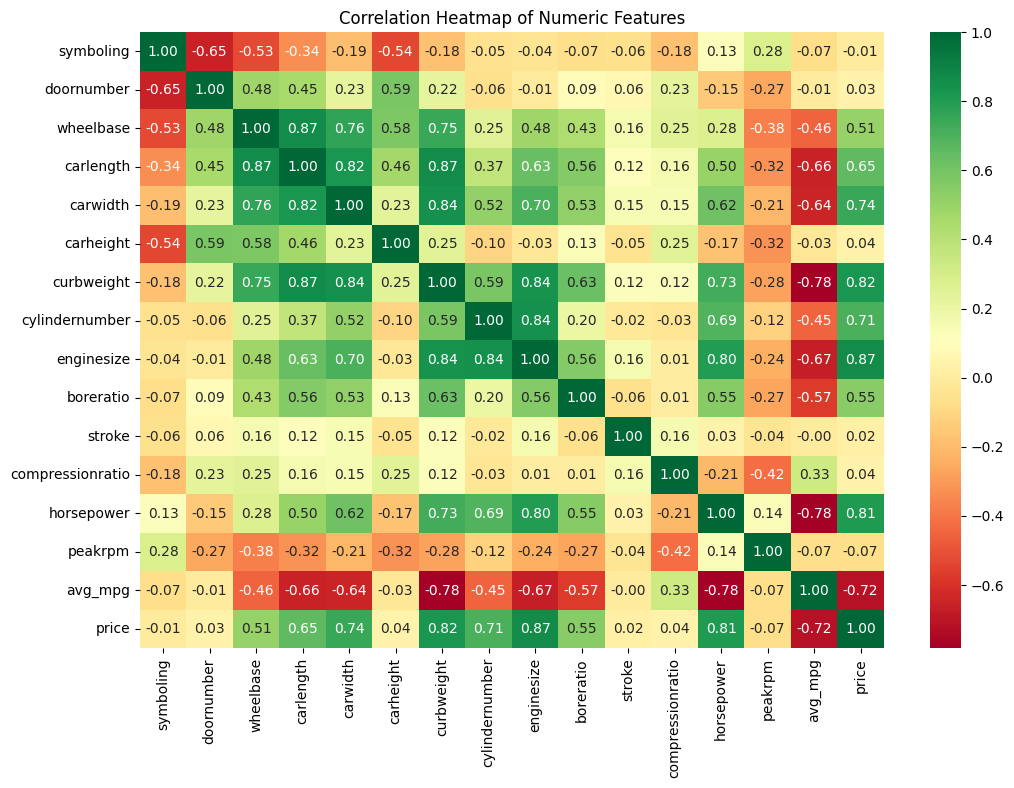

In [221]:
# Combined X_train and y_train for a temporary correlation check
temp_df = X_train.copy()
temp_df['price'] = y_train

plt.figure(figsize=(12, 8))
sns.heatmap(temp_df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

## Step 4: VIF (Multicollinearity Removal)


In [222]:
def get_vif_df(data):
    num_data = data.select_dtypes(include=[np.number])
    X_c = sm.add_constant(num_data)
    vif = pd.DataFrame({'feature': X_c.columns, 'VIF': [variance_inflation_factor(X_c.values, i) for i in range(X_c.shape[1]) ]})
    return vif[vif['feature'] != 'const']

curr_X = X_train.copy()
while True:
    vif_res = get_vif_df(curr_X)
    if vif_res['VIF'].max() > 10:
        drop_feat = vif_res.sort_values('VIF', ascending=False)['feature'].iloc[0]
        curr_X = curr_X.drop(columns=[drop_feat])
    else: break

X_train, X_test = curr_X, X_test[curr_X.columns]
display(get_vif_df(X_train))

,feature,VIF
1,symboling,2.678865
2,doornumber,2.520465
3,wheelbase,8.227151
4,carlength,8.970890
5,carwidth,5.189048
6,carheight,2.297774
7,cylindernumber,3.180783
8,boreratio,2.584223
9,stroke,1.171600
10,compressionratio,1.796990


In [223]:
# Re-running VIF with a stricter threshold of 5.0
curr_X = X_train.copy()
while True:
    vif_res = get_vif_df(curr_X)
    # Using 5 as the professional threshold
    if vif_res['VIF'].max() > 5:
        drop_feat = vif_res.sort_values('VIF', ascending=False)['feature'].iloc[0]
        print(f"Dropping {drop_feat} due to high VIF")
        curr_X = curr_X.drop(columns=[drop_feat])
    else:
        break

X_train, X_test = curr_X, X_test[curr_X.columns]
display(get_vif_df(X_train))

Dropping carlength due to high VIF
Dropping horsepower due to high VIF
Dropping wheelbase due to high VIF


,feature,VIF
1,symboling,2.044986
2,doornumber,2.119994
3,carwidth,2.934331
4,carheight,1.881337
5,cylindernumber,1.727423
6,boreratio,1.920683
7,stroke,1.128097
8,compressionratio,1.721310
9,peakrpm,1.505453
10,avg_mpg,3.273995


## Step 5: Model Training (Pipeline)

In [224]:
num_f = X_train.select_dtypes(include=[np.number]).columns
cat_f = X_train.select_dtypes(exclude=[np.number]).columns

# log-transformed targets
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_f),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_f)
])

models = {'Linear': LinearRegression(), 'Ridge': Ridge(alpha=1.0), 'Lasso': Lasso(alpha=0.01)}
results = {}

for name, m in models.items():
    pipe = Pipeline([('pre', preprocessor), ('model', m)])
    pipe.fit(X_train, y_train_log)
    p = np.expm1(pipe.predict(X_test))
    results[name] = {'r2': r2_score(y_test, p), 'pipe': pipe}
    print(f"{name} R2: {results[name]['r2']:.3f}")

Linear R2: 0.898
Ridge R2: 0.890
Lasso R2: 0.820


In [225]:
metrics = []
for n, i in results.items():
    p = np.expm1(i['pipe'].predict(X_test))
    metrics.append({
        'Model': n,
        'R2': round(r2_score(y_test, p), 3),
        'MAE': f"${mean_absolute_error(y_test, p):,.0f}",
        'RMSE': f"${np.sqrt(mean_squared_error(y_test, p)):,.0f}",
        'MAPE': f"{mean_absolute_percentage_error(y_test, p)*100:.1f}%"
    })

display(pd.DataFrame(metrics))

,Model,R2,MAE,RMSE,MAPE
0,Linear,0.898,"$1,704","$2,842",11.8%
1,Ridge,0.890,"$1,624","$2,953",11.6%
2,Lasso,0.820,"$2,145","$3,767",14.3%


## Step 6: Visualization: Comparing actual vs predicted values for our best performing model.

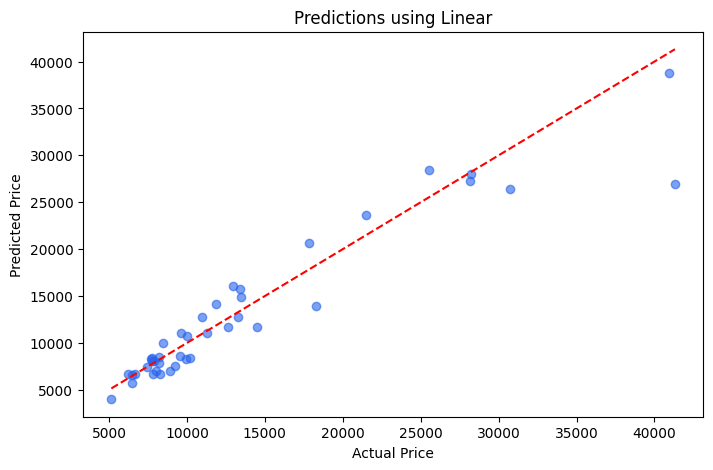

In [226]:
best_n = max(results, key=lambda k: results[k]['r2'])
best_p = results[best_n]['pipe']
preds = np.expm1(best_p.predict(X_test))

plt.figure(figsize=(8, 5))
plt.scatter(y_test, preds, alpha=0.6, color='#2563eb')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Predictions using {best_n}')
plt.show()

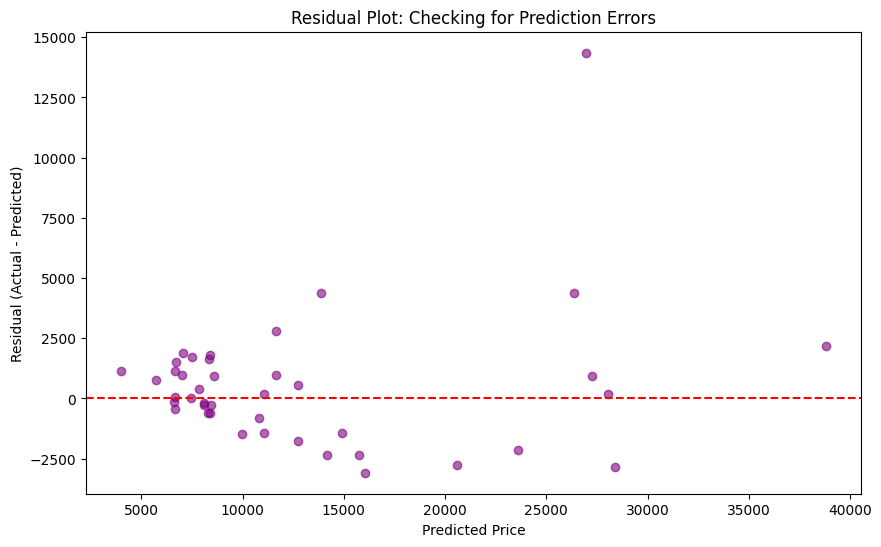

In [227]:
# We use 'preds' here because that is what we named our predictions in the previous cell
# This plot helps us check if our model's errors (residuals) are random or show a pattern
residuals = y_test - preds

plt.figure(figsize=(10, 6))
plt.scatter(preds, residuals, alpha=0.6, color='purple')
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot: Checking for Prediction Errors")
plt.show()

## Step 7: Feature Importance

In [228]:
# The results from the best model
best_pipe = results[best_n]['pipe']
model_step = best_pipe.named_steps['model']
preprocessor = best_pipe.named_steps['pre']

# The feature names after OneHotEncoding
cat_encoder = preprocessor.named_transformers_['cat']
cat_features = list(cat_encoder.get_feature_names_out(cat_f))
all_features = list(num_f) + cat_features

coefs = pd.DataFrame(
    {"Feature": all_features, "Coefficient": model_step.coef_}
)

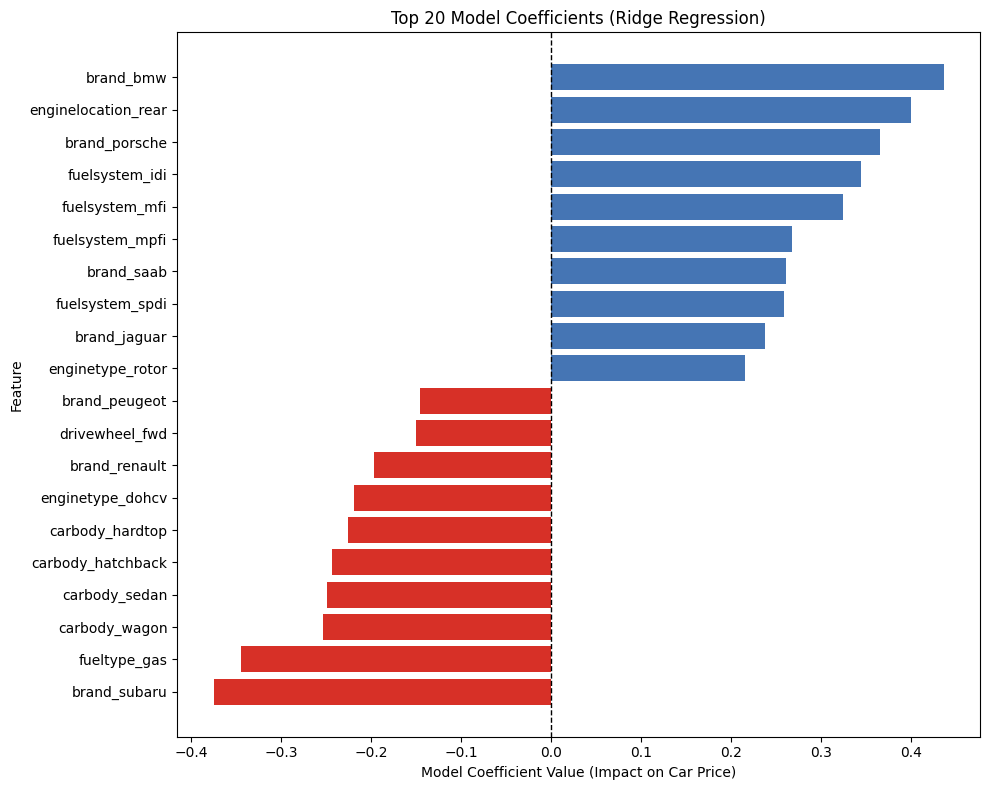

In [229]:
# Top 10 Positive and Top 10 Negative coefficients
top_pos = coefs.sort_values(by="Coefficient", ascending=False).head(10)
top_neg = coefs.sort_values(by="Coefficient", ascending=True).head(10)
plot_df = pd.concat([top_pos, top_neg]).sort_values(by="Coefficient")

# Plot
plt.figure(figsize=(10, 8))
plt.barh(plot_df["Feature"], plot_df["Coefficient"], color=colors)
plt.axvline(0, color="black", linestyle="--", linewidth=1)

plt.xlabel("Model Coefficient Value (Impact on Car Price)")
plt.ylabel("Feature")
plt.title("Top 20 Model Coefficients (Ridge Regression)")
plt.tight_layout()
plt.show()

## Step 8: Conclusion

Car prices in this dataset are primarily driven by brand prestige (BMW/Porsche) and physical dimensions (car width), which serve as proxies for luxury and segment size.



The model is highly reliable for mid-range vehicles but suggests that engine location and fuel systems are critical differentiators for high-end pricing.